C:\Users\Artem\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


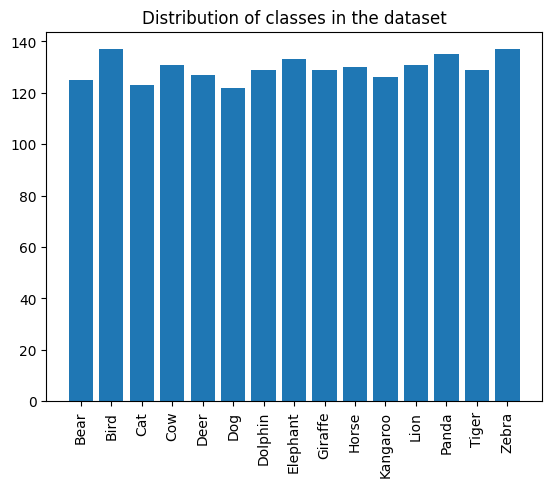

Class: Bear


C:\Users\Artem\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\cuda\CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


Text animal: cat
Image animal: Cat
Pipeline result: True
(None, 'Cat', False)
('dog', 'Cat', False)
('cat dog', 'Cat', True)


In [1]:
# Demo Notebook: Animal NER + Image Classification Pipeline

##  Problem Description
# We build a pipeline:
# - NER extracts the name of the animal from the text
# - Classifier identifies the animal in the image
# - Pipeline returns True/False whether the text matches the image

import os
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torchvision import models, transforms, datasets
from PIL import Image
import torch.nn as nn
import matplotlib.pyplot as plt

# --- Functions from pipeline.py ---
def extract_animal(text, ner_model_dir, device):
    tokenizer = AutoTokenizer.from_pretrained(ner_model_dir)
    model = AutoModelForTokenClassification.from_pretrained(ner_model_dir).to(device)
    inputs = tokenizer(text.split(), is_split_into_words=True,
                       return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    id2label = model.config.id2label

    animals = []
    for token, pred_id in zip(tokens, predictions):
        if token not in ["[CLS]", "[SEP]", "[PAD]"]:
            label = id2label[pred_id]
            if label != "O":
                animals.append(token)
    return " ".join(animals) if animals else None

def classify_image(image_path, clf_model_dir, device):
    with open(os.path.join(clf_model_dir, "classes.txt"), "r") as f:
        class_names = [line.strip() for line in f.readlines()]
    num_classes = len(class_names)

    model = models.resnet50(weights=None)  # легша модель
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load(
    os.path.join(clf_model_dir, "animal_classifier.pth"),
    map_location=device,
    weights_only=True
    ))
    model = model.to(device)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, pred = torch.max(outputs, 1)

    return class_names[pred.item()]

def pipeline(text, image_path, ner_model_dir, clf_model_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    animal_text = extract_animal(text, ner_model_dir, device)
    animal_image = classify_image(image_path, clf_model_dir, device)
    result = (animal_text is not None) and any(
    token.lower() == animal_image.lower() for token in animal_text.split()
    )
    return animal_text, animal_image, result

##  EDA: Class distribution in a dataset
data_dir = "C:/Users/Artem/animal_data"
dataset = datasets.ImageFolder(data_dir)
classes = dataset.classes
counts = [len([x for x in dataset.samples if x[1]==i]) for i in range(len(classes))]

plt.bar(classes, counts)
plt.xticks(rotation=90)
plt.title("Distribution of classes in the dataset")
plt.show()

##  Example image
img_path, label = dataset.samples[0]
Image.open(img_path).show()
print("Class:", classes[label])

##  Pipeline demonstration
ner_model_dir = "C:/Users/Artem/ner_model"
clf_model_dir = "C:/Users/Artem/classifier_model"
image_path = "C:/Users/Artem/test_images/Cat_1_2.jpg"

text = "There is a cat in the picture."
animal_text, animal_image, result = pipeline(text, image_path, ner_model_dir, clf_model_dir)
print("Text animal:", animal_text)
print("Image animal:", animal_image)
print("Pipeline result:", result)

## Edge cases
# Text without an animal
text = "There is a tree in the picture."
print(pipeline(text, image_path, ner_model_dir, clf_model_dir))

# Text and image do not match
text = "There is a dog in the picture."
print(pipeline(text, image_path, ner_model_dir, clf_model_dir))

# Multiple animals in the text
text = "I see a cat and a dog together."
print(pipeline(text, image_path, ner_model_dir, clf_model_dir))
